# SED Study

In [1]:
import numpy as np
import dask.array as da
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import healpy as hp
import matplotlib.pyplot as plt
import pyccl as ccl

from simulMap import *
from fitMap import *
from lumMag_sampling import *
from mappers import DepthMapper, CountMapper
from spectra import Spectrum

# Set random seed for reproducibility
#np.random.seed(42)

## Reference spectrum

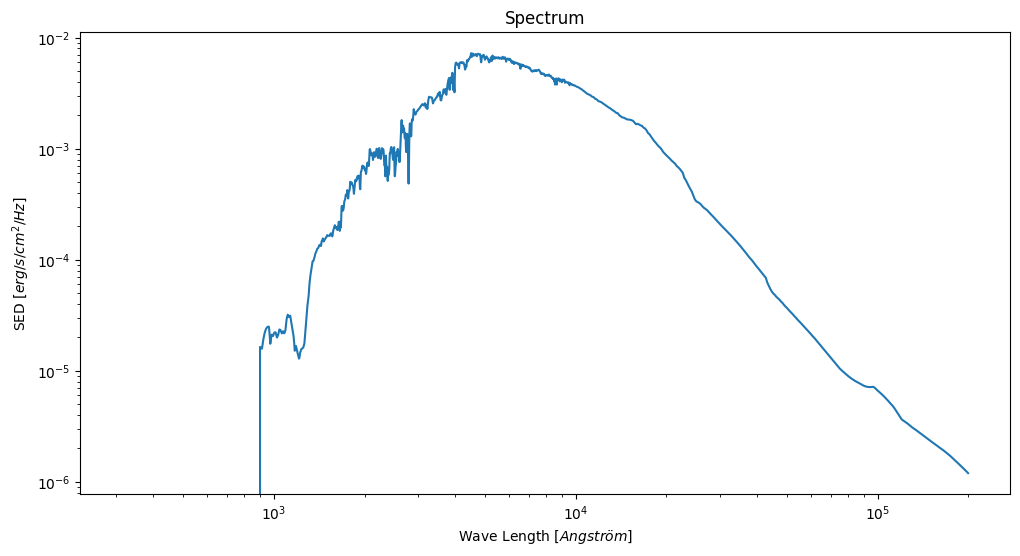

In [2]:
file = "../data/data SED/SED GAL/COSMOS/Ell1_A_0.sed"
refSpectum = Spectrum.read_sed(file)
refSpectum.plot(loglog=True);

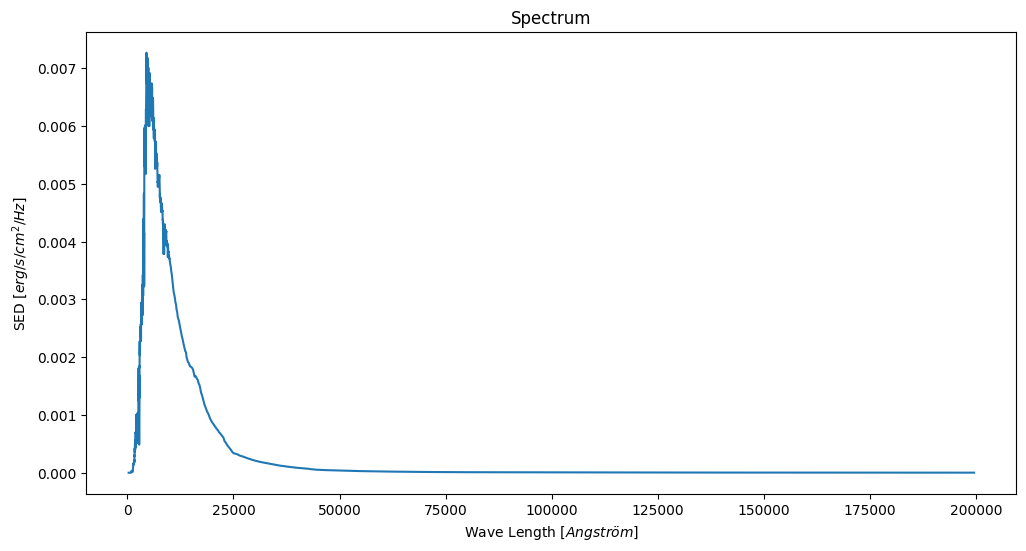

In [3]:
refSpectum.plot(loglog=False);

In [4]:
refSpectum.get_bands()
refSpectum.bands_name

['u', 'g', 'r', 'i', 'z', 'y']

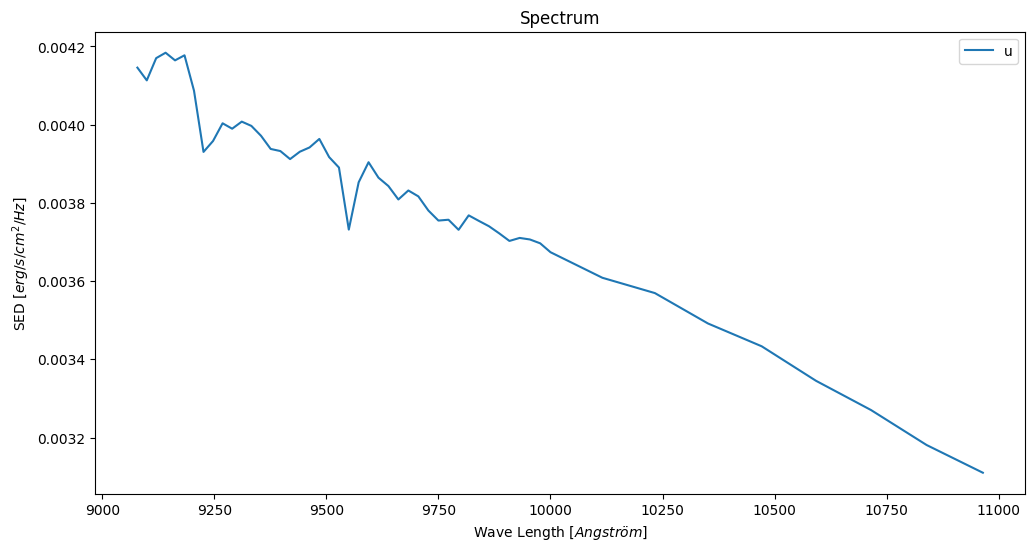

In [5]:
refSpectum.plot(band="y", loglog=False, label="u");

## Band Filtres

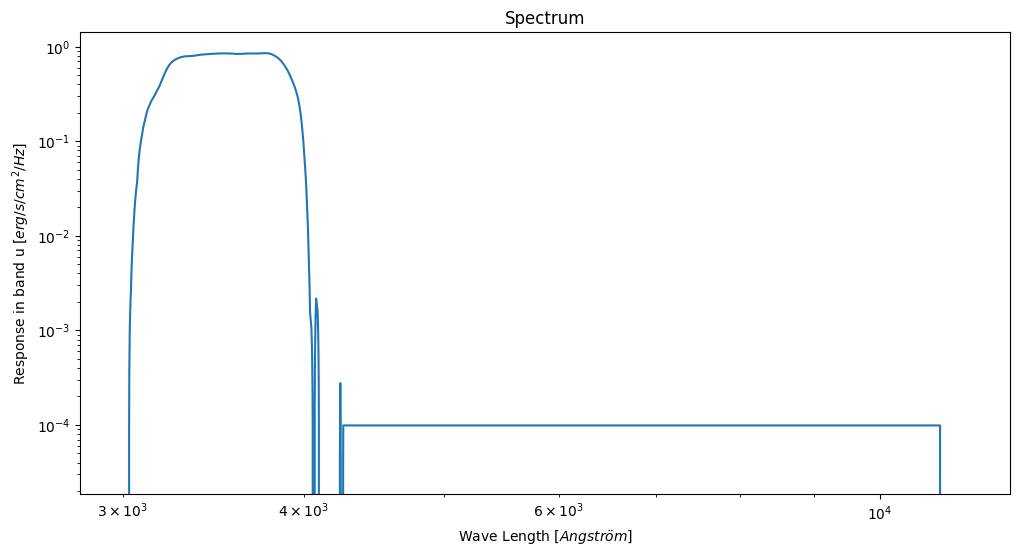

In [6]:
band = 'u'
file_band = f"../data/data LSST/filter_{band}.dat"
uFilter = Spectrum.read_sed(file_band, yname=f"Response in band {band}")
uFilter.wavelength = uFilter.wavelength*10
uFilter.plot(loglog=True);

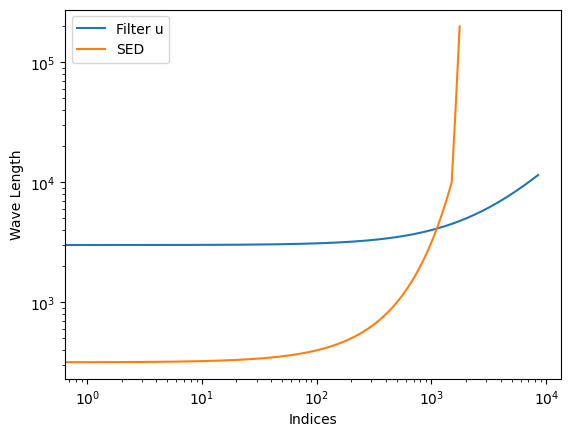

In [7]:
plt.plot(uFilter.wavelength, label=f'Filter {band}')
plt.plot(refSpectum.wavelength, label='SED')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Indices')
plt.ylabel("Wave Length");

In [8]:
integral = refSpectum.integrate()
print(f"SED integral : {integral}")

SED integral : 63.2951480487615


In [9]:
_, response = refSpectum.get_surrounding(uFilter)
response = response.mean(axis=0)
integral = refSpectum.integrate(response)
print(f"SED band {band} integral : {integral}")

SED band u integral : 1.9955105540435094


In [10]:
ratio = refSpectum.ratio_integrate(response)
print(f"SED band {band} ratio : {ratio}")

SED band u ratio : 0.031527069855436664
